In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")


In [40]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [41]:
if "Person ID" in df.columns:
    df.drop(columns=["Person ID"], inplace=True)

df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})

if "Blood Pressure" in df.columns:
    df[["Systolic_BP", "Diastolic_BP"]] = (
        df["Blood Pressure"].astype(str).str.split("/", expand=True).astype(int)
    )
    df.drop(columns=["Blood Pressure"], inplace=True)

X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [42]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [43]:
# Original stratified 80/20 train/test split (random_state=42 for reproducibility).
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train/Test sizes: {len(X_train)}/{len(X_test)}")


Train/Test sizes: 299/75


In [44]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="mlogloss",
    random_state=42
)


In [45]:
stack_clf = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=4000),
    stack_method="predict_proba",  
    n_jobs=-1
)


In [46]:
stacking_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", stack_clf)
])


In [47]:
stacking_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Sleep Duration',
                                                   'Quality of Sleep',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps', 'Systolic_BP',
                                                   'Diastolic_BP']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category'])])),
                ('classifier',
                 StackingClassifier(estimat...
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=5,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=200,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=42, ...))],
                                    final_estimator=LogisticRegression(max_iter=4000),
                                    n_jobs=-1, stack_method='predict_proba'))])

In [48]:
y_pred = stacking_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"STACKING ACCURACY: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


STACKING ACCURACY: 94.67%

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.88        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.95        75
   macro avg       0.92      0.92      0.91        75
weighted avg       0.95      0.95      0.95        75


Confusion Matrix:
 [[14  0  1]
 [ 0 44  0]
 [ 3  0 13]]


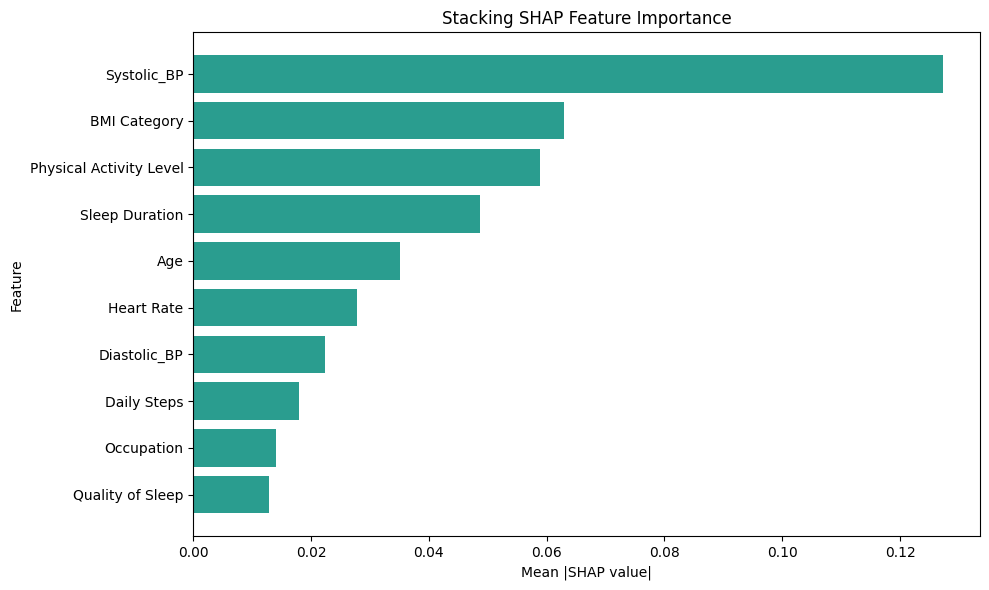

In [49]:
# Requires shap and lime; install from requirements.txt.
import shap

model_label = "Stacking"
explain_model = stacking_model

feature_names = X_train.columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [col for col in feature_names if col not in categorical_cols]

# Encode categorical features so SHAP and LIME can work on the raw input space.
category_maps = {}
encoded_train = X_train.copy()
encoded_test = X_test.copy()

for col in categorical_cols:
    categories = list(pd.Index(X_train[col].astype(str).unique()))
    mapping = {value: idx for idx, value in enumerate(categories)}
    category_maps[col] = mapping
    encoded_train[col] = X_train[col].astype(str).map(mapping).astype(float)
    encoded_test[col] = X_test[col].astype(str).map(mapping).astype(float)


def decode_encoded_frame(encoded_array):
    encoded_array = np.asarray(encoded_array)
    if encoded_array.ndim == 1:
        encoded_array = encoded_array.reshape(1, -1)
    decoded = pd.DataFrame(encoded_array, columns=feature_names)
    for col in categorical_cols:
        inverse_map = {code: label for label, code in category_maps[col].items()}
        codes = pd.to_numeric(decoded[col], errors="coerce").fillna(0).round().astype(int)
        codes = codes.clip(0, len(inverse_map) - 1)
        decoded[col] = codes.map(inverse_map)
    for col in numerical_cols:
        decoded[col] = pd.to_numeric(decoded[col], errors="coerce")
    return decoded


def predict_proba_from_encoded(encoded_array):
    return explain_model.predict_proba(decode_encoded_frame(encoded_array))

encoded_train_array = encoded_train[feature_names].to_numpy(dtype=float)
encoded_test_array = encoded_test[feature_names].to_numpy(dtype=float)

background = shap.sample(encoded_train_array, min(30, len(encoded_train_array)), random_state=42)
sample_rows = encoded_test_array[:min(10, len(encoded_test_array))]

masker = shap.maskers.Independent(background)
shap_explainer = shap.Explainer(
    predict_proba_from_encoded,
    masker,
    feature_names=feature_names,
    algorithm="permutation",
)
shap_values = shap_explainer(sample_rows)

if shap_values.values.ndim == 3:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

top_shap = shap_importance.head(10).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_shap.index, top_shap.values, color="#2a9d8f")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"{model_label} SHAP Feature Importance")
plt.tight_layout()
plt.show()


Actual label: Insomnia
Predicted label: Insomnia
Prediction probabilities: {'Insomnia': 0.9036, 'None': 0.0593, 'Sleep Apnea': 0.0371}


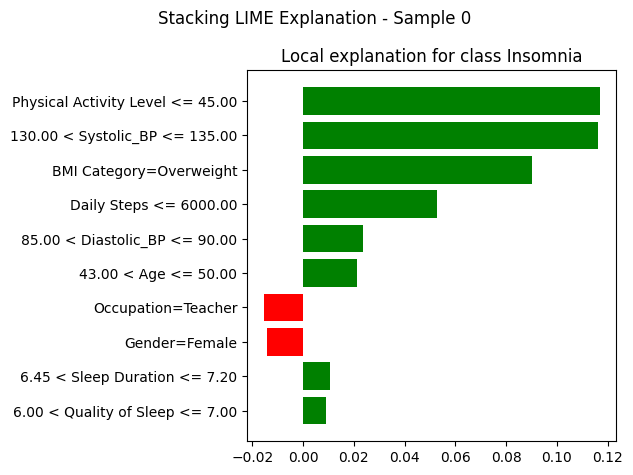

In [50]:
from lime.lime_tabular import LimeTabularExplainer

categorical_feature_indices = [feature_names.index(col) for col in categorical_cols]
categorical_names = {
    feature_names.index(col): list(category_maps[col].keys())
    for col in categorical_cols
}

lime_explainer = LimeTabularExplainer(
    training_data=encoded_train_array,
    feature_names=feature_names,
    class_names=list(le.classes_),
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

sample_idx = 0
sample_instance = encoded_test_array[sample_idx]
sample_probs = predict_proba_from_encoded(sample_instance)[0]
sample_pred_idx = int(np.argmax(sample_probs))
sample_pred_label = le.inverse_transform([sample_pred_idx])[0]
sample_true_label = le.inverse_transform([int(np.asarray(y_test)[sample_idx])])[0]

lime_exp = lime_explainer.explain_instance(
    sample_instance,
    predict_proba_from_encoded,
    num_features=min(10, len(feature_names)),
    top_labels=1,
)

print("Actual label:", sample_true_label)
print("Predicted label:", sample_pred_label)
print("Prediction probabilities:", dict(zip(le.classes_, np.round(sample_probs, 4))))

fig = lime_exp.as_pyplot_figure(label=sample_pred_idx)
fig.suptitle(f"{model_label} LIME Explanation - Sample {sample_idx}")
fig.tight_layout()
plt.show()


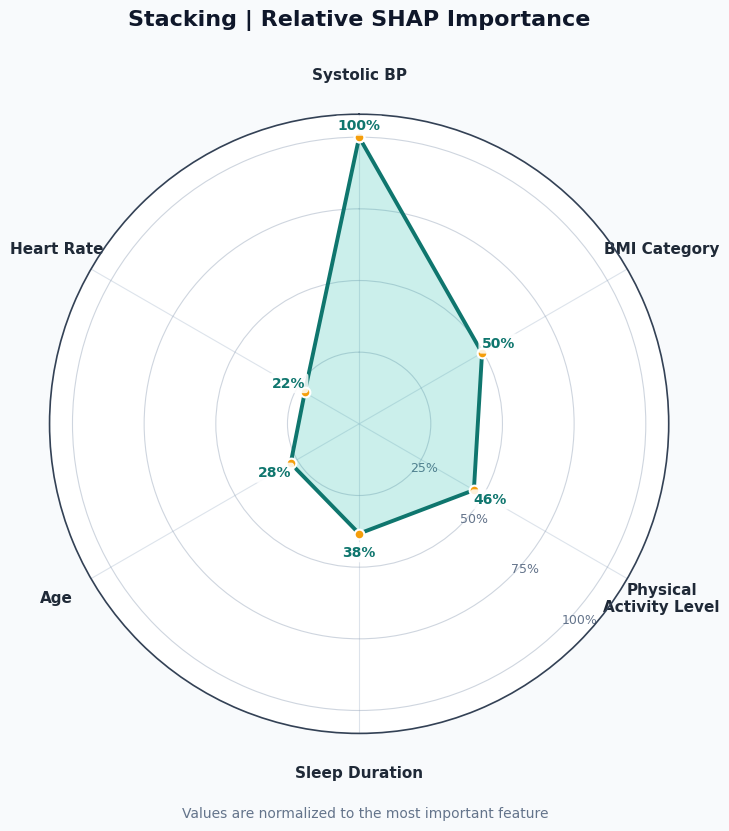

In [51]:
import textwrap

top_n = min(6, len(shap_importance))
radar_importance = shap_importance.head(top_n)
raw_values = radar_importance.to_numpy(dtype=float)
max_value = raw_values.max() if len(raw_values) else 0
radar_values = raw_values / max_value if max_value > 0 else np.zeros_like(raw_values)
radar_values_pct = radar_values * 100

angles = np.linspace(0, 2 * np.pi, top_n, endpoint=False)
closed_angles = np.concatenate([angles, [angles[0]]])
closed_values = np.concatenate([radar_values, [radar_values[0]]])
feature_labels = [textwrap.fill(str(name).replace("_", " "), width=14) for name in radar_importance.index]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
fig.patch.set_facecolor("#f8fafc")
ax.set_facecolor("#ffffff")
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(closed_angles, closed_values, color="#0f766e", linewidth=2.8, marker="o", markersize=7, markerfacecolor="#f59e0b", markeredgecolor="white", markeredgewidth=1.5, zorder=3)
ax.fill(closed_angles, closed_values, color="#14b8a6", alpha=0.22, zorder=2)
ax.set_xticks(angles)
ax.set_xticklabels(feature_labels, fontsize=11, fontweight="semibold", color="#1f2937")
ax.tick_params(axis="x", pad=18)
ax.set_ylim(0, 1.08)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=9, color="#64748b")
ax.set_rlabel_position(135)
ax.yaxis.grid(True, color="#94a3b8", alpha=0.45, linewidth=0.8)
ax.xaxis.grid(True, color="#cbd5e1", alpha=0.65, linewidth=0.8)
ax.spines["polar"].set_color("#334155")
ax.spines["polar"].set_linewidth(1.2)
for angle, value in zip(angles, radar_values_pct):
    ax.text(angle, min(value / 100 + 0.065, 1.04), f"{value:.0f}%", ha="center", va="center", fontsize=10, fontweight="bold", color="#0f766e", bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax.set_title(f"{model_label} | Relative SHAP Importance", fontsize=16, fontweight="bold", color="#0f172a", pad=30)
fig.text(0.5, 0.035, "Values are normalized to the most important feature", ha="center", fontsize=10, color="#64748b")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


## PCA visualisation (diagnostic only)

The PCA projection below is used only to inspect class separability in two dimensions. It is **not** included in the stacking classifier pipeline, so the classifier continues to use the complete preprocessed feature set.


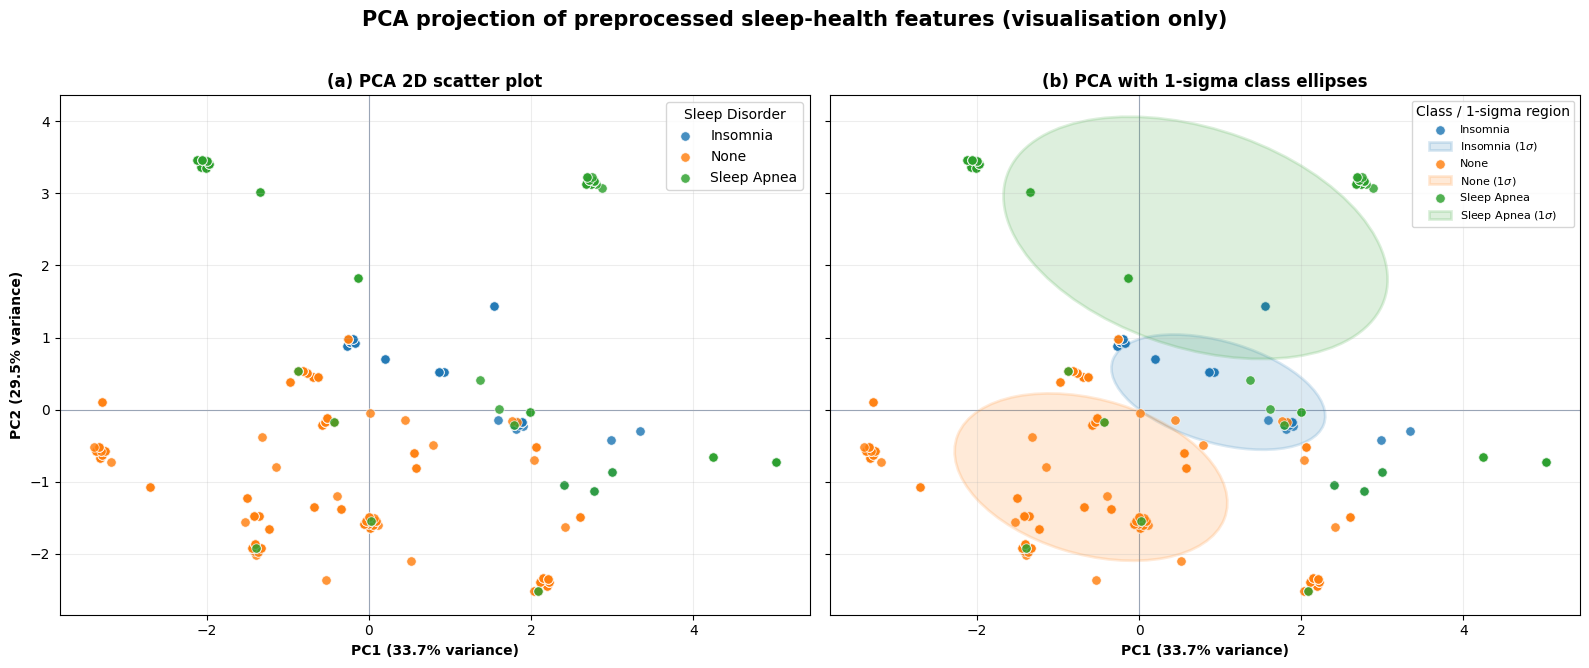

Explained variance — PC1: 33.68%, PC2: 29.47%, total: 63.14%
Note: PCA is not part of the stacking_model pipeline.


In [52]:
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# This transformer is intentionally separate from `stacking_model`: PCA is for visual diagnosis only.
pca_numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
pca_categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
pca_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), pca_numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), pca_categorical_cols),
    ]
)

X_pca_ready = pca_preprocessor.fit_transform(X)
# PCA expects a dense array; ColumnTransformer may return a sparse matrix after one-hot encoding.
if hasattr(X_pca_ready, "toarray"):
    X_pca_ready = X_pca_ready.toarray()

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_pca_ready)
pca_plot_df = pd.DataFrame(
    principal_components, columns=["PC1", "PC2"]
)
pca_plot_df["Sleep Disorder"] = le.inverse_transform(y_encoded)
explained_variance = pca.explained_variance_ratio_ * 100

def add_one_sigma_ellipse(x_values, y_values, axis, color, label):
    """Add a covariance-based 1-sigma ellipse for one class."""
    if len(x_values) < 2:
        return
    covariance = np.cov(x_values, y_values)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        xy=(np.mean(x_values), np.mean(y_values)),
        width=2 * np.sqrt(max(eigenvalues[0], 0)),
        height=2 * np.sqrt(max(eigenvalues[1], 0)),
        angle=angle, facecolor=color, edgecolor=color, alpha=0.16, linewidth=2, label=label
    )
    axis.add_patch(ellipse)

classes = list(le.classes_)
colors = dict(zip(classes, sns.color_palette("tab10", n_colors=len(classes))))
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)

for class_name in classes:
    class_points = pca_plot_df[pca_plot_df["Sleep Disorder"] == class_name]
    for axis in axes:
        axis.scatter(
            class_points["PC1"], class_points["PC2"],
            s=46, alpha=0.82, color=colors[class_name],
            edgecolor="white", linewidth=0.55, label=class_name
        )
    add_one_sigma_ellipse(
        class_points["PC1"].to_numpy(), class_points["PC2"].to_numpy(),
        axes[1], colors[class_name], f"{class_name} (1$\\sigma$)"
    )

for axis in axes:
    axis.axhline(0, color="#94a3b8", linewidth=0.8, zorder=0)
    axis.axvline(0, color="#94a3b8", linewidth=0.8, zorder=0)
    axis.grid(alpha=0.22)
    axis.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)", fontweight="bold")
axes[0].set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)", fontweight="bold")
axes[0].set_title("(a) PCA 2D scatter plot", fontweight="bold")
axes[1].set_title("(b) PCA with 1-sigma class ellipses", fontweight="bold")
axes[0].legend(title="Sleep Disorder", frameon=True)
axes[1].legend(title="Class / 1-sigma region", frameon=True, fontsize=8)
fig.suptitle("PCA projection of preprocessed sleep-health features (visualisation only)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Explained variance — PC1: {explained_variance[0]:.2f}%, PC2: {explained_variance[1]:.2f}%, total: {explained_variance.sum():.2f}%")
print("Note: PCA is not part of the stacking_model pipeline.")


## Spearman correlation and 2D ALE visualisation

This figure is generated from the fitted stacking classifier. The ALE surface shows the local joint effect of **Sleep Duration** and **Quality of Sleep** on the selected class probability.

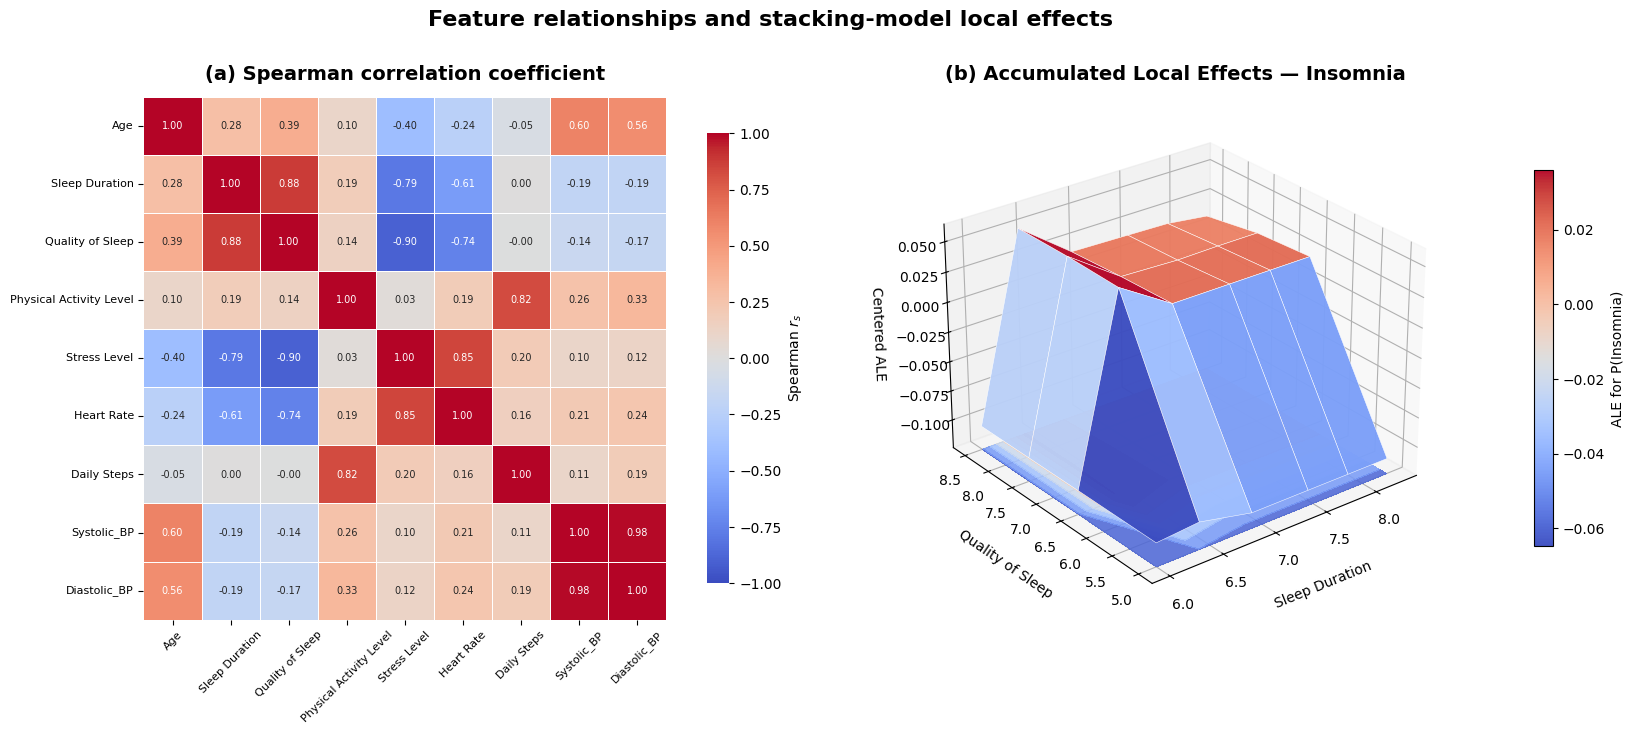

In [53]:
# Run this cell after fitting `stacking_model` (Cell 9).
from matplotlib import cm

def two_dimensional_ale(model, data, feature_x, feature_y, class_index, n_bins=6):
    """Return a centred 2D ALE surface for one classifier probability."""
    x_values = pd.to_numeric(data[feature_x], errors="coerce").to_numpy(dtype=float)
    y_values = pd.to_numeric(data[feature_y], errors="coerce").to_numpy(dtype=float)
    usable = np.isfinite(x_values) & np.isfinite(y_values)
    data = data.loc[usable].copy()
    x_values, y_values = x_values[usable], y_values[usable]

    x_edges = np.unique(np.quantile(x_values, np.linspace(0, 1, n_bins + 1)))
    y_edges = np.unique(np.quantile(y_values, np.linspace(0, 1, n_bins + 1)))
    if len(x_edges) < 3 or len(y_edges) < 3:
        raise ValueError("Choose ALE features with at least two distinct values.")

    x_bin = np.clip(np.digitize(x_values, x_edges[1:-1]), 0, len(x_edges) - 2)
    y_bin = np.clip(np.digitize(y_values, y_edges[1:-1]), 0, len(y_edges) - 2)
    local_effects = np.zeros((len(x_edges) - 1, len(y_edges) - 1))
    counts = np.zeros_like(local_effects)
    batches, locations = [], []

    # Build all four corner predictions at once, keeping the cell fast.
    for i in range(local_effects.shape[0]):
        for j in range(local_effects.shape[1]):
            mask = (x_bin == i) & (y_bin == j)
            if not mask.any():
                continue
            block = data.iloc[np.flatnonzero(mask)].copy()
            corners = []
            for x_corner, y_corner in (
                (x_edges[i], y_edges[j]),
                (x_edges[i], y_edges[j + 1]),
                (x_edges[i + 1], y_edges[j]),
                (x_edges[i + 1], y_edges[j + 1]),
            ):
                corner = block.copy()
                corner[feature_x] = x_corner
                corner[feature_y] = y_corner
                corners.append(corner)
            batches.extend(corners)
            locations.append((i, j, len(block)))

    probabilities = model.predict_proba(pd.concat(batches, ignore_index=True))[:, class_index]
    offset = 0
    for i, j, block_size in locations:
        f_ll, f_lh, f_hl, f_hh = (
            probabilities[offset + k * block_size : offset + (k + 1) * block_size]
            for k in range(4)
        )
        local_effects[i, j] = np.mean(f_hh - f_hl - f_lh + f_ll)
        counts[i, j] = block_size
        offset += 4 * block_size

    ale_surface = np.cumsum(np.cumsum(local_effects, axis=0), axis=1)
    observed = counts > 0
    ale_surface -= np.average(ale_surface[observed], weights=counts[observed])
    x_centres = (x_edges[:-1] + x_edges[1:]) / 2
    y_centres = (y_edges[:-1] + y_edges[1:]) / 2
    return x_centres, y_centres, ale_surface


# (a) Spearman correlation coefficient for the numeric sleep-health variables.
numeric_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()
spearman_corr = X_train[numeric_features].corr(method="spearman")

# (b) ALE is calculated for Insomnia when it is available; otherwise use the first class.
ale_features = [name for name in ["Sleep Duration", "Quality of Sleep"] if name in numeric_features]
if len(ale_features) < 2:
    ale_features = numeric_features[:2]
target_class = "Insomnia" if "Insomnia" in le.classes_ else le.classes_[0]
target_class_index = list(le.classes_).index(target_class)
x_grid, y_grid, ale_values = two_dimensional_ale(
    stacking_model, X_train, ale_features[0], ale_features[1], target_class_index
)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing="ij")

fig = plt.figure(figsize=(18, 7.2), facecolor="white")
ax_corr = fig.add_subplot(1, 2, 1)
sns.heatmap(
    spearman_corr, ax=ax_corr, cmap="coolwarm", vmin=-1, vmax=1, center=0,
    square=True, annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.45, linecolor="white", cbar_kws={"label": "Spearman $r_s$", "shrink": 0.86}
)
ax_corr.set_title("(a) Spearman correlation coefficient", fontsize=14, fontweight="bold", pad=12)
ax_corr.tick_params(axis="x", rotation=45, labelsize=8)
ax_corr.tick_params(axis="y", rotation=0, labelsize=8)

ax_ale = fig.add_subplot(1, 2, 2, projection="3d")
surface = ax_ale.plot_surface(
    X_grid, Y_grid, ale_values, cmap=cm.coolwarm, linewidth=0.35,
    edgecolor=("white"), antialiased=True, alpha=0.96
)
z_min, z_max = ale_values.min(), ale_values.max()
z_padding = max((z_max - z_min) * 0.08, 1e-4)
ax_ale.contourf(X_grid, Y_grid, ale_values, zdir="z", offset=z_min - z_padding, cmap=cm.coolwarm, alpha=0.86)
ax_ale.set_zlim(z_min - z_padding, z_max + z_padding)
ax_ale.view_init(elev=27, azim=-128)
ax_ale.set_xlabel(ale_features[0], labelpad=10)
ax_ale.set_ylabel(ale_features[1], labelpad=10)
ax_ale.set_zlabel("Centered ALE", labelpad=9)
ax_ale.set_title(f"(b) Accumulated Local Effects — {target_class}", fontsize=14, fontweight="bold", pad=12)
colorbar = fig.colorbar(surface, ax=ax_ale, shrink=0.72, pad=0.12)
colorbar.set_label(f"ALE for P({target_class})")
fig.suptitle("Feature relationships and stacking-model local effects", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## Multiclass ROC–AUC evaluation

The following plot reports one-vs-rest ROC curves for each sleep-disorder class, together with micro- and macro-average ROC–AUC scores.

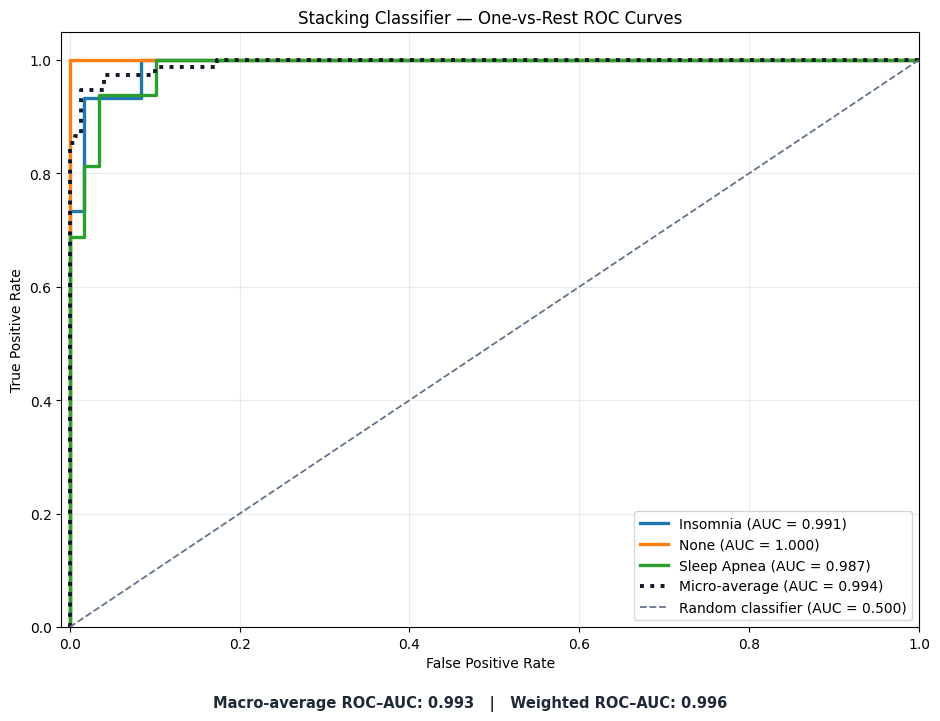

ROC–AUC scores (one-vs-rest):
  Insomnia: 0.9911
  None: 1.0000
  Sleep Apnea: 0.9873
Macro-average ROC–AUC:    0.9928
Weighted ROC–AUC:         0.9955
Micro-average ROC–AUC:    0.9941


In [54]:
from itertools import cycle
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Predicted class probabilities from the fitted stacking pipeline.
y_test_array = np.asarray(y_test)
class_ids = np.arange(len(le.classes_))
y_test_binarized = label_binarize(y_test_array, classes=class_ids)
y_score = stacking_model.predict_proba(X_test)

# ROC–AUC is calculated one-vs-rest because this is a multiclass problem.
per_class_auc = {}
fpr, tpr = {}, {}
for class_id, class_name in enumerate(le.classes_):
    fpr[class_id], tpr[class_id], _ = roc_curve(y_test_binarized[:, class_id], y_score[:, class_id])
    per_class_auc[class_name] = auc(fpr[class_id], tpr[class_id])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
micro_auc = auc(fpr["micro"], tpr["micro"])
macro_auc = roc_auc_score(y_test_array, y_score, multi_class="ovr", average="macro")
weighted_auc = roc_auc_score(y_test_array, y_score, multi_class="ovr", average="weighted")

fig, ax = plt.subplots(figsize=(9.5, 7.2), facecolor="white")
palette = cycle(sns.color_palette("tab10", n_colors=len(le.classes_)))
for class_id, (class_name, color) in enumerate(zip(le.classes_, palette)):
    ax.plot(
        fpr[class_id], tpr[class_id], color=color, lw=2.4,
        label=f"{class_name} (AUC = {per_class_auc[class_name]:.3f})"
    )

ax.plot(
    fpr["micro"], tpr["micro"], color="#111827", linestyle=":", lw=2.8,
    label=f"Micro-average (AUC = {micro_auc:.3f})"
)
ax.plot([0, 1], [0, 1], color="#64748b", linestyle="--", lw=1.3, label="Random classifier (AUC = 0.500)")
ax.set(
    xlim=(-0.01, 1.0), ylim=(0.0, 1.05), xlabel="False Positive Rate",
    ylabel="True Positive Rate", title="Stacking Classifier — One-vs-Rest ROC Curves"
)
ax.grid(alpha=0.24)
ax.legend(loc="lower right", frameon=True)
fig.text(
    0.5, 0.01, f"Macro-average ROC–AUC: {macro_auc:.3f}   |   Weighted ROC–AUC: {weighted_auc:.3f}",
    ha="center", fontsize=10.5, fontweight="semibold", color="#1f2937"
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

print("ROC–AUC scores (one-vs-rest):")
for class_name, score in per_class_auc.items():
    print(f"  {class_name}: {score:.4f}")
print(f"Macro-average ROC–AUC:    {macro_auc:.4f}")
print(f"Weighted ROC–AUC:         {weighted_auc:.4f}")
print(f"Micro-average ROC–AUC:    {micro_auc:.4f}")


## All-model comparison and stacking ablation study

Every model is evaluated on the same stratified train/test split. The ablation study measures the contribution of Random Forest and XGBoost to the stacking ensemble.

,Model,Train accuracy,Test accuracy,Macro F1,Macro ROC-AUC
0,KNN,0.903,0.947,0.928,0.996
1,SVM,0.913,0.973,0.957,0.995
2,Full Stacking (RF + XGB),0.923,0.947,0.914,0.993
3,Soft Voting (RF + XGB),0.926,0.933,0.901,0.992
4,Random Forest,0.926,0.947,0.921,0.991
5,XGBoost,0.916,0.947,0.914,0.986
6,Logistic Regression,0.910,0.947,0.920,0.986
7,Gradient Boosting,0.926,0.947,0.921,0.983
8,Decision Tree,0.926,0.947,0.930,0.951


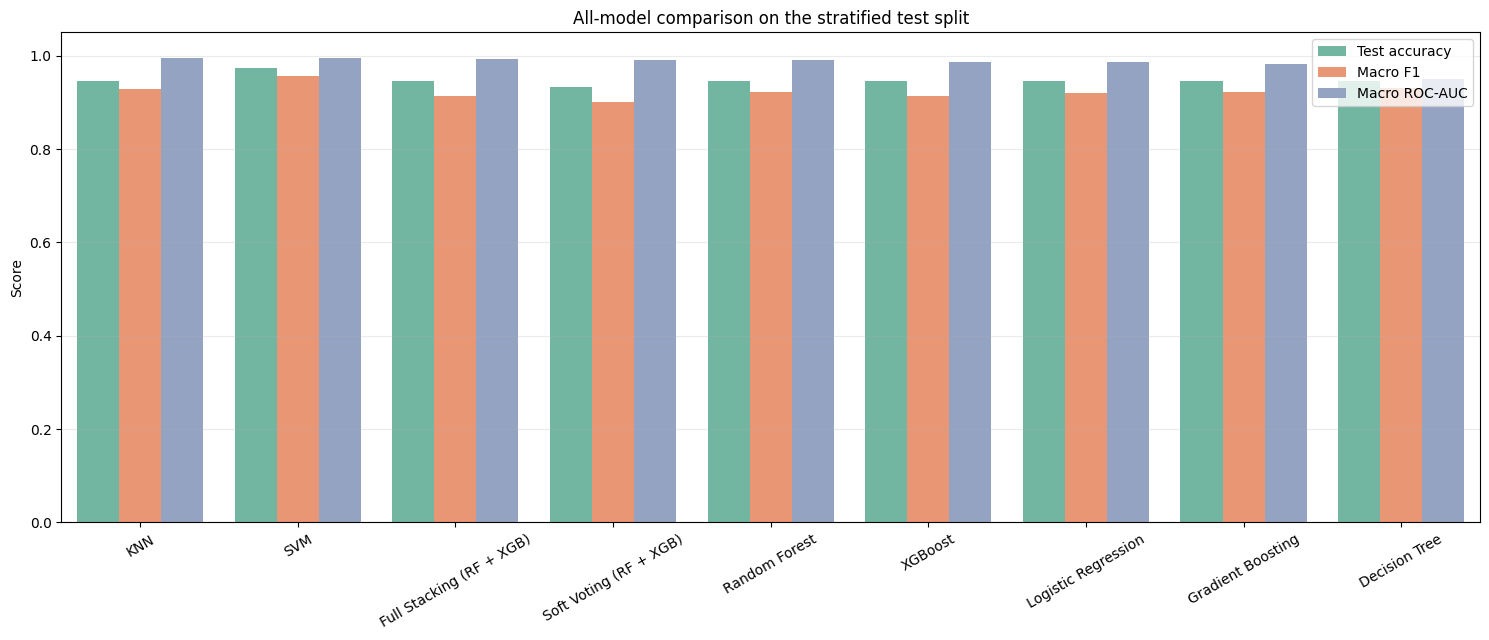

In [ ]:
# Run after fitting `stacking_model` in Cell 9.
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

def comparison_pipe(classifier):
    return Pipeline([("preprocessor", clone(preprocessor)), ("classifier", classifier)])

def comparison_rf(seed=42):
    return RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1)

def comparison_xgb(seed=42):
    return XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, eval_metric="mlogloss", random_state=seed, n_jobs=-1)

# Random Forest + XGBoost soft-voting ensemble from random_xgbo_voting.ipynb.
voting_model = VotingClassifier(
    estimators=[("rf", comparison_pipe(comparison_rf())), ("xgb", comparison_pipe(comparison_xgb()))],
    voting="soft", n_jobs=-1,
)

comparison_models = {
    "Logistic Regression": comparison_pipe(LogisticRegression(max_iter=4000, random_state=42)),
    "Decision Tree": comparison_pipe(DecisionTreeClassifier(random_state=42)),
    "KNN": comparison_pipe(KNeighborsClassifier(n_neighbors=5)),
    "SVM": comparison_pipe(SVC(kernel="rbf", probability=True, random_state=42)),
    "Gradient Boosting": comparison_pipe(GradientBoostingClassifier(random_state=42)),
    "Random Forest": comparison_pipe(comparison_rf()),
    "XGBoost": comparison_pipe(comparison_xgb()),
    "Soft Voting (RF + XGB)": voting_model,
    "Full Stacking (RF + XGB)": stacking_model,
}

def evaluate(name, model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        "Model": name,
        "Train accuracy": accuracy_score(y_train, train_pred),
        "Test accuracy": accuracy_score(y_test, test_pred),
        "Macro F1": f1_score(y_test, test_pred, average="macro", zero_division=0),
        "Macro ROC-AUC": roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr", average="macro"),
    }

fitted_comparison_models, comparison_rows = {}, []
for name, model in comparison_models.items():
    if name != "Full Stacking (RF + XGB)":
        model.fit(X_train, y_train)
    fitted_comparison_models[name] = model
    comparison_rows.append(evaluate(name, model))

model_comparison_df = pd.DataFrame(comparison_rows).sort_values(["Macro ROC-AUC", "Test accuracy"], ascending=False).reset_index(drop=True)
display(model_comparison_df.style.format({"Train accuracy": "{:.3f}", "Test accuracy": "{:.3f}", "Macro F1": "{:.3f}", "Macro ROC-AUC": "{:.3f}"}))

comparison_plot = model_comparison_df.melt(id_vars="Model", value_vars=["Test accuracy", "Macro F1", "Macro ROC-AUC"], var_name="Metric", value_name="Score")
plt.figure(figsize=(15, 6.5))
ax = sns.barplot(data=comparison_plot, x="Model", y="Score", hue="Metric", palette="Set2")
ax.set(title="All-model comparison on the stratified test split", xlabel="", ylabel="Score", ylim=(0, 1.05))
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="")
plt.tight_layout()
plt.show()

# Ablation study: retain one base learner at a time, then compare with full stacking.
def reduced_stacking(estimators):
    return comparison_pipe(StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(max_iter=4000), stack_method="predict_proba", n_jobs=-1))

ablation_models = {
    "RF only": fitted_comparison_models["Random Forest"],
    "XGBoost only": fitted_comparison_models["XGBoost"],
    "Soft voting (RF + XGB)": fitted_comparison_models["Soft Voting (RF + XGB)"],
    "Stacking without RF": reduced_stacking([("xgb", comparison_xgb())]),
    "Stacking without XGBoost": reduced_stacking([("rf", comparison_rf())]),
    "Full stacking (RF + XGB)": stacking_model,
}

ablation_rows = []
for name, model in ablation_models.items():
    if name.startswith("Stacking without"):
        model.fit(X_train, y_train)
    ablation_rows.append(evaluate(name, model))

ablation_df = pd.DataFrame(ablation_rows).sort_values("Macro ROC-AUC", ascending=False).reset_index(drop=True)
display(ablation_df.style.format({"Train accuracy": "{:.3f}", "Test accuracy": "{:.3f}", "Macro F1": "{:.3f}", "Macro ROC-AUC": "{:.3f}"}))

ablation_plot = ablation_df.melt(id_vars="Model", value_vars=["Test accuracy", "Macro F1", "Macro ROC-AUC"], var_name="Metric", value_name="Score")
plt.figure(figsize=(13, 6.5))
ax = sns.barplot(data=ablation_plot, x="Model", y="Score", hue="Metric", palette="muted")
ax.set(title="Stacking ablation study — Random Forest and XGBoost contribution", xlabel="Model variant", ylabel="Test-set score", ylim=(0, 1.05))
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="")
plt.tight_layout()
plt.show()
